In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# emd_path_folder = "D:/pythonProject/TEM_Data_Analysis_ML/data/20251207_EELS_dataset/"
# emd_path_folder = "D:/pythonProject/TEM_Data_Analysis_ML/data/0106-20260118_2105/"
# emd_path_folder = "E:/AAA-Data in Argonne/20260313 0.2%MoleFraction KNO3 EELS/"
emd_path_folder = "Demo/"
emd_file = "0008-20260215_1412_DF_6600_x-EELS-(RT, 0.2mol%HNO3).emd"
custom_file = "0008-20260215_1412_(RT, 0.2mol%HNO3)_"

emd_path = emd_path_folder + emd_file

def list_datasets(g, parent=""):
    for key in g.keys():
        item = g[key]
        path = f"{parent}/{key}"
        if isinstance(item, h5py.Dataset):
            print("[DATASET]", path, "shape:", item.shape, "dtype:", item.dtype)
        elif isinstance(item, h5py.Group):
            print("[GROUP  ]", path)
            list_datasets(item, path)

with h5py.File(emd_path, "r") as f:
    list_datasets(f)
# 对于 EELS SI：shape = (50, 2048, 50)，维度顺序是：( Y , Energy , X )




# # --- 打开 EMD 文件 ---
# with h5py.File(emd_path, "r") as f:
#     # 通常使用第一个 Dataset：/Data/..., 但不同设备路径可能不同
#     # 自动找出所有 Data 下的数据节点
#     def find_dataset(g):
#         ds_list = []
#         g.visititems(lambda name, obj: ds_list.append(name) if isinstance(obj, h5py.Dataset) else None)
#         return ds_list

#     datasets = find_dataset(f["Data"])
#     print("Datasets found:\n", datasets)

#     # 通常 EELS SI 数据是 "Data/Data"
#     si = f["Data/Data"][()]
#     dims = f["Data/Dimensions"][()]

# print("SI shape:", si.shape)
# print("Dimensions:", dims)


[GROUP  ] /Application
[GROUP  ] /Application/Velox
[DATASET] /Application/Velox/DisplayLayout shape: (1,) dtype: object
[GROUP  ] /Data
[GROUP  ] /Data/EelsSpectrumImage
[GROUP  ] /Data/EelsSpectrumImage/54a99287cf924194ac244fd16f37a1ce
[DATASET] /Data/EelsSpectrumImage/54a99287cf924194ac244fd16f37a1ce/AcquisitionMetadata shape: (752, 16) dtype: uint8
[DATASET] /Data/EelsSpectrumImage/54a99287cf924194ac244fd16f37a1ce/Data shape: (30, 2048, 16) dtype: uint32
[DATASET] /Data/EelsSpectrumImage/54a99287cf924194ac244fd16f37a1ce/Info shape: (1,) dtype: object
[DATASET] /Data/EelsSpectrumImage/54a99287cf924194ac244fd16f37a1ce/Metadata shape: (60000, 1) dtype: uint8
[GROUP  ] /Data/EelsSpectrumImage/5aadde5924dc4aa1a55698361d20526b
[DATASET] /Data/EelsSpectrumImage/5aadde5924dc4aa1a55698361d20526b/AcquisitionMetadata shape: (752, 16) dtype: uint8
[DATASET] /Data/EelsSpectrumImage/5aadde5924dc4aa1a55698361d20526b/Data shape: (30, 2048, 16) dtype: uint32
[DATASET] /Data/EelsSpectrumImage/5aadde

# 一、Python 代码：读取你的 EELS Spectrum Image (SI)

In [9]:
with h5py.File(emd_path, "r") as f:
    group_LL = f["/Data/EelsSpectrumImage/5aadde5924dc4aa1a55698361d20526b"] # low loss SI
    
    group_CL1 = f["/Data/EelsSpectrumImage/8bac7e346b444a1aaf002611a0f16316"] # Core loss 1 SI
    group_CL2 = f["/Data/EelsSpectrumImage/54a99287cf924194ac244fd16f37a1ce"] # Core loss 2 SI
    group_CL3 = f["/Data/EelsSpectrumImage/b408f69a1f084a519e542c486b42b273"] # Core loss 3 SI
    
    
    
    # 读取光谱图数据
    si_raw_LL = group_LL["Data"][()]     
    si_raw_CL1 = group_CL1["Data"][()]    
    si_raw_CL2 = group_CL2["Data"][()]    
    si_raw_CL3 = group_CL3["Data"][()]   
    
    
    

print("Raw SI_LL shape:", si_raw_LL.shape)
print("Raw SI_CL1 shape:", si_raw_CL1.shape)
print("Raw SI_CL2 shape:", si_raw_CL2.shape)
print("Raw SI_CL3 shape:", si_raw_CL3.shape)




Raw SI_LL shape: (30, 2048, 16)
Raw SI_CL1 shape: (30, 2048, 16)
Raw SI_CL2 shape: (30, 2048, 16)
Raw SI_CL3 shape: (30, 2048, 16)


# 二、将 (Y, E, X) → 转换为标准 (Y, X, E)

In [12]:
# rearrange to (Y, X, Energy)
si_LL = np.moveaxis(si_raw_LL, 1, -1)  # 把 Energy 轴从中间移到最后
si_CL1 = np.moveaxis(si_raw_CL1, 1, -1)  # 把 Energy 轴从中间移到最后
si_CL2= np.moveaxis(si_raw_CL2, 1, -1)  # 把 Energy 轴从中间移到最后
si_CL3= np.moveaxis(si_raw_CL3, 1, -1)  # 把 Energy 轴从中间移到最后



print("Reordered SI_LL:", si_LL.shape)
print("Reordered SI_CL1:", si_CL1.shape)
print("Reordered SI_CL2:", si_CL2.shape)
print("Reordered SI_CL3:", si_CL3.shape)






Reordered SI_LL: (30, 16, 2048)
Reordered SI_CL1: (30, 16, 2048)
Reordered SI_CL2: (30, 16, 2048)
Reordered SI_CL3: (30, 16, 2048)


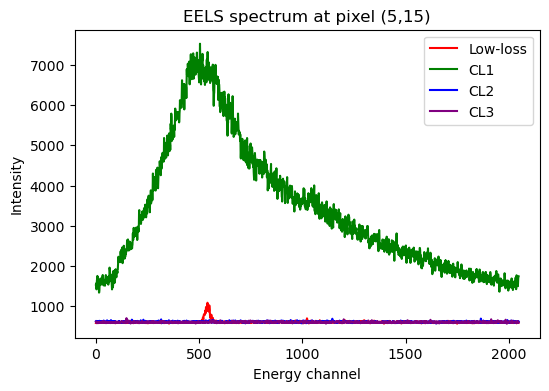

In [14]:
x, y = 5, 15
spectrum_LL = si_LL[y, x, :]     # 1D 光谱
spectrum_CL1 = si_CL1[y, x, :]     # 1D 光谱
spectrum_CL2 = si_CL2[y, x, :]     # 1D 光谱
spectrum_CL3 = si_CL3[y, x, :]     # 1D 光谱



plt.figure(figsize=(6,4))
plt.plot(spectrum_LL, 'red', label="Low-loss")
plt.plot(spectrum_CL1, 'green', label="CL1")
plt.plot(spectrum_CL2, 'blue', label="CL2")
plt.plot(spectrum_CL3, 'purple', label="CL3")


plt.title(f"EELS spectrum at pixel ({x},{y})")
plt.xlabel("Energy channel")
plt.ylabel("Intensity")
plt.legend()
plt.show()


# 三、Energy scale calibration

In [19]:
import numpy as np

n_energy = 2048

dE = 0.035    # eV per channel, energy dispersion
offset_LL = -20.0  # eV, velox provide the effset of low loss energy offset
offset_CL1 = 3.0  # eV, velox provide the effset of low loss energy offset
offset_CL2 = 385.0  # eV, velox provide the effset of low loss energy offset
offset_CL3 = 510.0  # eV, velox provide the effset of low loss energy offset



energy_axis_LL = offset_LL + dE * np.arange(n_energy)
energy_axis_CL1 = offset_CL1 + dE * np.arange(n_energy)
energy_axis_CL2 = offset_CL2 + dE * np.arange(n_energy)
energy_axis_CL3 = offset_CL3 + dE * np.arange(n_energy)


print("Energy axis range:", energy_axis_LL[0], "to", energy_axis_LL[-1])
print("Energy axis range:", energy_axis_CL1[0], "to", energy_axis_CL1[-1])
print("Energy axis range:", energy_axis_CL2[0], "to", energy_axis_CL2[-1])
print("Energy axis range:", energy_axis_CL3[0], "to", energy_axis_CL3[-1])



Energy axis range: -20.0 to 51.64500000000001
Energy axis range: 3.0 to 74.64500000000001
Energy axis range: 385.0 to 456.645
Energy axis range: 510.0 to 581.645


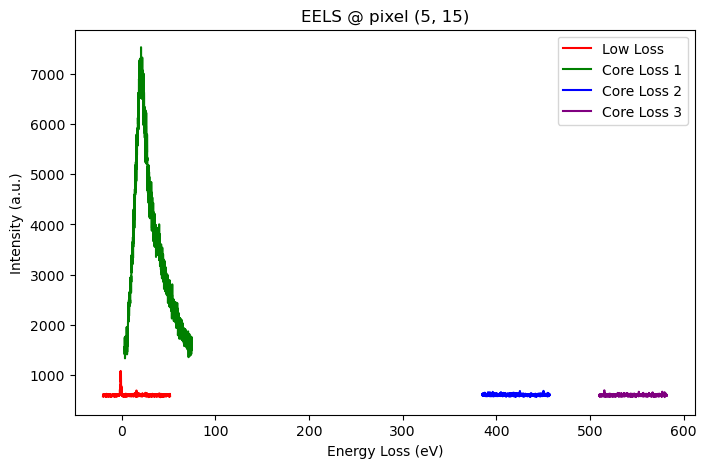

In [21]:
# Check the SI 

plt.figure(figsize=(8,5))

plt.plot(energy_axis_LL, spectrum_LL, 'red', label="Low Loss")
plt.plot(energy_axis_CL1, spectrum_CL1, 'green', label="Core Loss 1")
plt.plot(energy_axis_CL2, spectrum_CL2, 'blue', label="Core Loss 2")
plt.plot(energy_axis_CL3, spectrum_CL3, 'purple', label="Core Loss 3")



plt.xlabel("Energy Loss (eV)")
plt.ylabel("Intensity (a.u.)")
plt.title(f"EELS @ pixel ({x}, {y})")

# plt.xlim(385, 600)   # 示例，可自行调节
# plt.ylim(370, 500)
plt.legend()
plt.show()


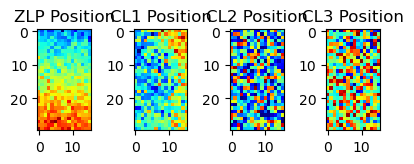

In [23]:
# px_nm = 58.84 # nm/pixel

zlp_pos = np.argmax(si_LL, axis=2)
CL1_edge = np.argmax(si_CL1, axis=2)
CL2_edge = np.argmax(si_CL2, axis=2)
CL3_edge = np.argmax(si_CL3, axis=2)


ny, nx = zlp_pos.shape  # 注意顺序：行(y), 列(x)


fig, axs = plt.subplots(1, 4, figsize=(4, 15))

axs[0].imshow(zlp_pos, cmap='jet')
axs[0].set_title("ZLP Position")

axs[1].imshow(CL1_edge, cmap='jet')
axs[1].set_title("CL1 Position")

axs[2].imshow(CL2_edge, cmap='jet')
axs[2].set_title("CL2 Position")

axs[3].imshow(CL3_edge, cmap='jet')
axs[3].set_title("CL3 Position")

plt.tight_layout()
plt.show()



# extent = [0, nx*px_nm, ny*px_nm, 0]  # [xmin, xmax, ymin, ymax]，单位 nm

# plt.figure()
# plt.imshow(zlp_pos, extent=extent, cmap='jet')
# plt.xlabel("x (nm)")
# plt.ylabel("y (nm)")
# plt.title("ZLP position map (channel index)")
# plt.colorbar(label="Channel index")
# plt.show()

# plt.figure()
# plt.imshow(Oxy_edge, extent=extent, cmap='jet')
# plt.xlabel("x (nm)")
# plt.ylabel("y (nm)")
# plt.title("O-K edge position map (channel index)")
# plt.colorbar(label="Channel index")
# plt.show()

In [25]:
import numpy as np
from scipy.optimize import curve_fit

def gaussian(x, A, x0, sigma, C):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + C


In [27]:
def zlp_gaussian_peak(spectrum, energy_axis, zlp_window=(-2, 5)):
    """
    对 ZLP 区域用 Gaussian 拟合，返回 sub-pixel ZLP 位置（单位：channel index）
    """

    # 选取 ZLP 区间
    mask = (energy_axis >= zlp_window[0]) & (energy_axis <= zlp_window[1])
    x = energy_axis[mask]
    y = spectrum[mask]

    # 初始猜测
    A0 = y.max() - y.min()
    x0 = x[np.argmax(y)]
    sigma0 = 0.5  # 随便一个初值
    C0 = y.min()

    try:
        popt, _ = curve_fit(gaussian, x, y, p0=[A0, x0, sigma0, C0])
        _, x0_fit, _, _ = popt   # x0_fit 是高斯中心
        # 将 x0_fit 转换成光谱 channel index
        return np.interp(x0_fit, energy_axis, np.arange(len(energy_axis)))
    except:
        # 拟合失败就退化成最大值法
        idx = np.argmax(y)
        return np.where(mask)[0][idx]


In [29]:
ny, nx, nE = si_LL.shape
zlp_gauss_map = np.zeros((ny, nx), dtype=float)

for y in range(ny):
    for x in range(nx):
        zlp_gauss_map[y, x] = zlp_gaussian_peak(si_LL[y, x], energy_axis_LL, zlp_window=(-10, 12)) #the energy range for fitting


In [31]:
# 参考光谱
ref_spec = si_LL.mean(axis=(0, 1))
ref_subpix = zlp_gaussian_peak(ref_spec, energy_axis_LL)


In [33]:
drift_channels = zlp_gauss_map - ref_subpix
drift_eV = drift_channels * dE


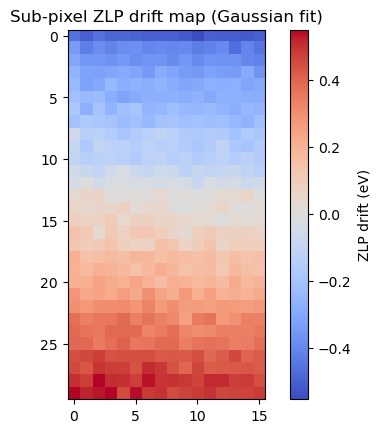

In [35]:
import matplotlib.pyplot as plt
plt.imshow(drift_eV, cmap='coolwarm')
plt.colorbar(label='ZLP drift (eV)')
plt.title('Sub-pixel ZLP drift map (Gaussian fit)')
plt.show()


In [37]:
from scipy.ndimage import fourier_shift
from numpy.fft import fft, ifft

aligned_si_LL = np.empty_like(si_LL, dtype=float)
aligned_si_CL1 = np.empty_like(si_CL1, dtype=float)
aligned_si_CL2 = np.empty_like(si_CL2, dtype=float)
aligned_si_CL3 = np.empty_like(si_CL3, dtype=float)



for y in range(ny):
    for x in range(nx):
        shift = ref_subpix - zlp_gauss_map[y, x]   # 正负号自动处理
        F_LL = fft(si_LL[y, x].astype(float))
        F_CL1 = fft(si_CL1[y, x].astype(float))
        F_CL2 = fft(si_CL2[y, x].astype(float))
        F_CL3 = fft(si_CL3[y, x].astype(float))
        
        
        
        F_shifted_LL = fourier_shift(F_LL, shift)
        F_shifted_CL1 = fourier_shift(F_CL1, shift)
        F_shifted_CL2 = fourier_shift(F_CL2, shift)
        F_shifted_CL3 = fourier_shift(F_CL3, shift)
        
        
        aligned_si_LL[y, x] = np.real(ifft(F_shifted_LL))
        aligned_si_CL1[y, x] = np.real(ifft(F_shifted_CL1))
        aligned_si_CL2[y, x] = np.real(ifft(F_shifted_CL2))
        aligned_si_CL3[y, x] = np.real(ifft(F_shifted_CL3))
        
        
        


In [39]:
# np.save("aligned_si_LL.npy", aligned_si_LL)
# np.save("aligned_si_Oxy.npy", aligned_si_Oxy)
# np.save("energy_axis_LL.npy", energy_axis_LL)
# np.save("energy_axis_Oxy.npy", energy_axis_Oxy)


# print("Saved aligned_si.npy and energy_axis.npy")

In [41]:
import hyperspy.api as hs
import exspy as ex
sig_LL = ex.signals.EELSSpectrum(aligned_si_LL)
sig_CL1 = ex.signals.EELSSpectrum(aligned_si_CL1)
sig_CL2 = ex.signals.EELSSpectrum(aligned_si_CL2)
sig_CL3 = ex.signals.EELSSpectrum(aligned_si_CL3)



sig_LL.set_signal_type("EELS")
sig_CL1.set_signal_type("EELS")
sig_CL2.set_signal_type("EELS")
sig_CL3.set_signal_type("EELS")



# 配置能量轴
sig_LL.axes_manager.signal_axes[0].scale = dE
sig_LL.axes_manager.signal_axes[0].offset = offset_LL
sig_LL.axes_manager.signal_axes[0].units = 'eV'
sig_LL.axes_manager.signal_axes[0].name = 'Energy loss'

sig_CL1.axes_manager.signal_axes[0].scale = dE
sig_CL1.axes_manager.signal_axes[0].offset = offset_CL1
sig_CL1.axes_manager.signal_axes[0].units = 'eV'
sig_CL1.axes_manager.signal_axes[0].name = 'Energy loss'

sig_CL2.axes_manager.signal_axes[0].scale = dE
sig_CL2.axes_manager.signal_axes[0].offset = offset_CL2
sig_CL2.axes_manager.signal_axes[0].units = 'eV'
sig_CL2.axes_manager.signal_axes[0].name = 'Energy loss'

sig_CL3.axes_manager.signal_axes[0].scale = dE
sig_CL3.axes_manager.signal_axes[0].offset = offset_CL3
sig_CL3.axes_manager.signal_axes[0].units = 'eV'
sig_CL3.axes_manager.signal_axes[0].name = 'Energy loss'

# 配置空间轴
pixel_size = 166.40  # nm
sig_LL.axes_manager.navigation_axes[0].scale = pixel_size
sig_LL.axes_manager.navigation_axes[0].units = "nm"
sig_LL.axes_manager.navigation_axes[1].scale = pixel_size
sig_LL.axes_manager.navigation_axes[1].units = "nm"

sig_CL1.axes_manager.navigation_axes[0].scale = pixel_size
sig_CL1.axes_manager.navigation_axes[0].units = "nm"
sig_CL1.axes_manager.navigation_axes[1].scale = pixel_size
sig_CL1.axes_manager.navigation_axes[1].units = "nm"

sig_CL2.axes_manager.navigation_axes[0].scale = pixel_size
sig_CL2.axes_manager.navigation_axes[0].units = "nm"
sig_CL2.axes_manager.navigation_axes[1].scale = pixel_size
sig_CL2.axes_manager.navigation_axes[1].units = "nm"

sig_CL3.axes_manager.navigation_axes[0].scale = pixel_size
sig_CL3.axes_manager.navigation_axes[0].units = "nm"
sig_CL3.axes_manager.navigation_axes[1].scale = pixel_size
sig_CL3.axes_manager.navigation_axes[1].units = "nm"


# # 保存
# sig_LL.save("aligned_si_LL.hspy")
# sig_N.save("aligned_si_N.hspy")
# sig_Oxy.save("aligned_si_Oxy.hspy")



# print("Saved aligned_si_LL.hspy")


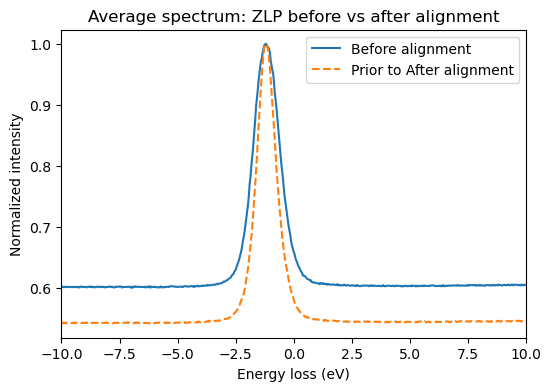

In [45]:
import numpy as np
import matplotlib.pyplot as plt

ny, nx, nE = si_LL.shape

# 全场平均谱
orig_mean_LL = si_LL.mean(axis=(0, 1))
aligned_mean_LL = aligned_si_LL.mean(axis=(0, 1))

# 归一化到最大值 = 1，便于比较
orig_mean_norm_LL = orig_mean_LL / orig_mean_LL.max()
aligned_mean_norm_LL = aligned_mean_LL / aligned_mean_LL.max()

plt.figure(figsize=(6, 4))
plt.plot(energy_axis_LL, orig_mean_norm_LL, label="Before alignment")
plt.plot(energy_axis_LL, aligned_mean_norm_LL, linestyle="--", label="Prior to After alignment")
plt.xlabel("Energy loss (eV)")
plt.ylabel("Normalized intensity")
plt.title("Average spectrum: ZLP before vs after alignment")
plt.legend()
plt.xlim(-10, 10)   # 放大 ZLP 周围，看清细节
plt.show()




In [47]:
import numpy as np

# 1) 全场平均谱（对齐后的）
avg_aligned_LL = aligned_si_LL.mean(axis=(0, 1))   # shape: (nE,)

# 2) 找最大值所在的 channel
idx_max = np.argmax(avg_aligned_LL)
E_max = energy_axis_LL[idx_max]   # 当前这个 channel 对应的能量（不是 0）

print("ZLP peak channel:", idx_max, "  E_max =", E_max, "eV")

# 3) 把这个能量定义为 0，重新生成能量轴
energy_axis_zero = energy_axis_LL - E_max


ZLP peak channel: 537   E_max = -1.2049999999999983 eV


In [49]:
new_offset_LL = offset_LL - E_max
new_offset_CL1 = offset_CL1 - E_max
new_offset_CL2 = offset_CL2 - E_max
new_offset_CL3 = offset_CL3 - E_max



sig_LL.axes_manager.signal_axes[0].offset = new_offset_LL
sig_CL1.axes_manager.signal_axes[0].offset = new_offset_CL1
sig_CL2.axes_manager.signal_axes[0].offset = new_offset_CL2
sig_CL3.axes_manager.signal_axes[0].offset = new_offset_CL3




print("New_offset_LL =", new_offset_LL, "eV (so ZLP ~ 0 eV now)")
print("New_offset_CL1 =", new_offset_CL1, "eV")
print("New_offset_CL2 =", new_offset_CL2, "eV")
print("New_offset_CL3 =", new_offset_CL3, "eV")




# 保存
sig_LL.save(f"{custom_file}aligned_si_rezero_LL.hspy")
sig_CL1.save(f"{custom_file}aligned_si_rezero_CL1.hspy")
sig_CL2.save(f"{custom_file}aligned_si_rezero_CL2.hspy")
sig_CL3.save(f"{custom_file}aligned_si_rezero_CL3.hspy")





New_offset_LL = -18.795 eV (so ZLP ~ 0 eV now)
New_offset_CL1 = 4.204999999999998 eV
New_offset_CL2 = 386.205 eV
New_offset_CL3 = 511.205 eV


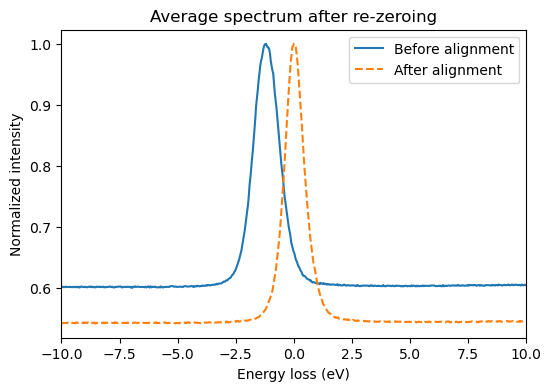

In [51]:
energy_axis_zero_LL = new_offset_LL + dE * np.arange(aligned_si_LL.shape[2])

orig_mean_LL = si_LL.mean(axis=(0, 1))
aligned_mean_LL = aligned_si_LL.mean(axis=(0, 1))
orig_mean_LL /= orig_mean_LL.max()
aligned_mean_LL /= aligned_mean_LL.max()

import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(energy_axis_LL, orig_mean_norm_LL, label="Before alignment")

# plt.plot(energy_axis_zero_LL, orig_mean_LL, label="Before alignment")
plt.plot(energy_axis_zero_LL, aligned_mean_LL, "--", label="After alignment")
plt.xlim(-10, 10)
plt.legend()
plt.xlabel("Energy loss (eV)")
plt.ylabel("Normalized intensity")
plt.title("Average spectrum after re-zeroing")

plt.show()


In [96]:
# import numpy as np
# import matplotlib.pyplot as plt

# aligned_energy_axis = energy_axis.copy()

# # ----- 选择一个 core-loss 范围，例如 O–K 在 ~500–600 eV -----
# emin = 500
# emax = 600

# mask_before = (energy_axis >= emin) & (energy_axis <= emax)
# mask_after = (aligned_energy_axis >= emin) & (aligned_energy_axis <= emax)

# # ----- 计算平均 core-loss 谱 -----
# avg_before = si.reshape(-1, si.shape[-1])[:, mask_before].mean(axis=0)
# avg_after  = aligned_si.reshape(-1, aligned_si.shape[-1])[:, mask_after].mean(axis=0)

# plt.figure(figsize=(7,5))
# plt.plot(energy_axis[mask_before], avg_before, label="Before alignment")
# plt.plot(aligned_energy_axis[mask_after], avg_after, label="After alignment", linestyle="--")

# plt.xlabel("Energy loss (eV)")
# plt.ylabel("Intensity (a.u.)")
# plt.title("Core-loss comparison (e.g., O–K edge)")
# plt.legend()
# plt.show()
